In [ ]:
# TASK 1: COLLECT BANKING COMPLAINT DATA

# Import pandas
import pandas as pd

# Create banking complaint data
data = {
    "Complaint_ID": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15
    ],

    "Customer": [
        "Customer1", "Customer2", "Customer3",
        "Customer4", "Customer5", "Customer6",
        "Customer7", "Customer8", "Customer9",
        "Customer10", "Customer11", "Customer12",
        "Customer13", "Customer14", "Customer15"
    ],

    "Complaint": [
        "My money was deducted from my account but the transaction failed",
        "The ATM did not give me cash but money was deducted",
        "I cannot login to my online banking account",
        "My home loan application is taking too long",
        "The bank charged me an incorrect transaction fee",
        "My account balance is not showing correctly",
        "I forgot my online banking password and cannot login",
        "My credit card payment was declined",
        "The loan interest rate is too high",
        "Money was transferred but the receiver did not get it",
        "The ATM card is not working",
        "I was charged a service fee without notification",
        "My account has been blocked",
        "Online banking website is not working",
        "My loan application was rejected"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display first 5 records
print("Banking Complaint Dataset:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Save dataset
df.to_csv("banking_complaints.csv", index=False)

print("\nDataset saved successfully!")

Banking Complaint Dataset:
   Complaint_ID   Customer                                          Complaint
0             1  Customer1  My money was deducted from my account but the ...
1             2  Customer2  The ATM did not give me cash but money was ded...
2             3  Customer3        I cannot login to my online banking account
3             4  Customer4        My home loan application is taking too long
4             5  Customer5   The bank charged me an incorrect transaction fee

Dataset Shape:
(15, 3)

Dataset saved successfully!


In [3]:
# TASK 2: PREPROCESS COMPLAINT TEXT

# Import libraries
import re
import nltk

# Download stopwords
nltk.download("stopwords")

# Import stopwords
from nltk.corpus import stopwords

# Get English stopwords
stop_words = set(stopwords.words("english"))


# Create cleaning function
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # Split text into words
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Join words
    return " ".join(words)


# Create cleaned complaint column
df["Clean_Complaint"] = df["Complaint"].apply(
    clean_text
)

# Display result
print("Cleaned Complaints:")

print(
    df[
        ["Complaint", "Clean_Complaint"]
    ].head(10)
)

Cleaned Complaints:
                                           Complaint  \
0  My money was deducted from my account but the ...   
1  The ATM did not give me cash but money was ded...   
2        I cannot login to my online banking account   
3        My home loan application is taking too long   
4   The bank charged me an incorrect transaction fee   
5        My account balance is not showing correctly   
6  I forgot my online banking password and cannot...   
7                My credit card payment was declined   
8                 The loan interest rate is too high   
9  Money was transferred but the receiver did not...   

                               Clean_Complaint  
0    money deducted account transaction failed  
1                 atm give cash money deducted  
2          cannot login online banking account  
3            home loan application taking long  
4       bank charged incorrect transaction fee  
5            account balance showing correctly  
6  forgot online ban

[nltk_data] Downloading package stopwords to C:\Users\ullas gowda
[nltk_data]     bu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# TASK 3: CATEGORIZE COMPLAINTS

# Create category function
def categorize_complaint(text):

    # Convert text to lowercase
    text = text.lower()

    # Transaction category
    if (
        "transaction" in text
        or "transferred" in text
        or "money was deducted" in text
        or "payment" in text
    ):
        return "Transaction"

    # Loan category
    elif (
        "loan" in text
        or "interest rate" in text
    ):
        return "Loan"

    # Online banking category
    elif (
        "online banking" in text
        or "login" in text
        or "password" in text
        or "website" in text
    ):
        return "Online Banking"

    # ATM or card category
    elif (
        "atm" in text
        or "card" in text
    ):
        return "ATM/Card"

    # Fee category
    elif (
        "fee" in text
        or "service fee" in text
    ):
        return "Fees"

    # Account category
    elif (
        "account" in text
        or "balance" in text
    ):
        return "Account Management"

    # Other
    else:
        return "Other"


# Apply category function
df["Category"] = df["Complaint"].apply(
    categorize_complaint
)

# Display categories
print("Complaint Categories:")

print(
    df[
        ["Complaint", "Category"]
    ]
)

Complaint Categories:
                                            Complaint            Category
0   My money was deducted from my account but the ...         Transaction
1   The ATM did not give me cash but money was ded...         Transaction
2         I cannot login to my online banking account      Online Banking
3         My home loan application is taking too long                Loan
4    The bank charged me an incorrect transaction fee         Transaction
5         My account balance is not showing correctly  Account Management
6   I forgot my online banking password and cannot...      Online Banking
7                 My credit card payment was declined         Transaction
8                  The loan interest rate is too high                Loan
9   Money was transferred but the receiver did not...         Transaction
10                        The ATM card is not working            ATM/Card
11   I was charged a service fee without notification                Fees
12              

In [5]:
# TASK 4: IDENTIFY FREQUENT BANKING ISSUES

# Count complaints by category
category_count = df["Category"].value_counts()

# Display result
print("Frequent Banking Issues:")
print(category_count)

Frequent Banking Issues:
Category
Transaction           5
Online Banking        3
Loan                  3
Account Management    2
ATM/Card              1
Fees                  1
Name: count, dtype: int64


In [6]:
# MOST COMMON BANKING ISSUE

# Find most common category
most_common_issue = category_count.idxmax()

# Find number of complaints
issue_count = category_count.max()

# Display result
print("Most Common Banking Issue:")
print(most_common_issue)

print("\nNumber of Complaints:")
print(issue_count)

Most Common Banking Issue:
Transaction

Number of Complaints:
5


In [8]:
# TASK 5: GENERATE ANALYTICAL REPORT

# Calculate total complaints
total_complaints = len(df)

# Find most common category
most_common_category = category_count.idxmax()

# Find number of complaints
most_common_count = category_count.max()


# Display report
print("==========================================")
print("       BANKING COMPLAINT ANALYSIS")
print("==========================================")

print("\nTotal Complaints:")
print(total_complaints)

print("\nMost Common Complaint Category:")
print(most_common_category)

print("\nNumber of Complaints:")
print(most_common_count)

print("\nComplaint Category Summary:")
print(category_count)

print("\nRecommendations:")

print(
    "1. Improve transaction processing."
)

print(
    "2. Improve online banking services."
)

print(
    "3. Reduce loan processing time."
)

print(
    "4. Provide better ATM and card services."
)

print(
    "5. Clearly explain banking fees to customers."
)

print(
    "6. Improve account management services."
)

print("==========================================")

       BANKING COMPLAINT ANALYSIS

Total Complaints:
15

Most Common Complaint Category:
Transaction

Number of Complaints:
5

Complaint Category Summary:
Category
Transaction           5
Online Banking        3
Loan                  3
Account Management    2
ATM/Card              1
Fees                  1
Name: count, dtype: int64

Recommendations:
1. Improve transaction processing.
2. Improve online banking services.
3. Reduce loan processing time.
4. Provide better ATM and card services.
5. Clearly explain banking fees to customers.
6. Improve account management services.


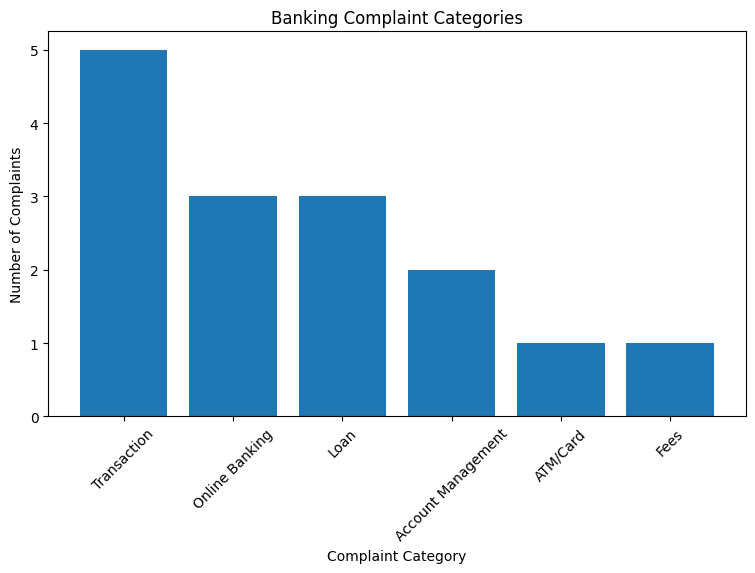

In [9]:
# COMPLAINT CATEGORY VISUALIZATION

import matplotlib.pyplot as plt

# Count categories
category_count = df["Category"].value_counts()

# Create bar chart
plt.figure(figsize=(9, 5))

plt.bar(
    category_count.index,
    category_count.values
)

# Add title
plt.title("Banking Complaint Categories")

# Add labels
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")

# Rotate labels
plt.xticks(rotation=45)

# Show graph
plt.show()

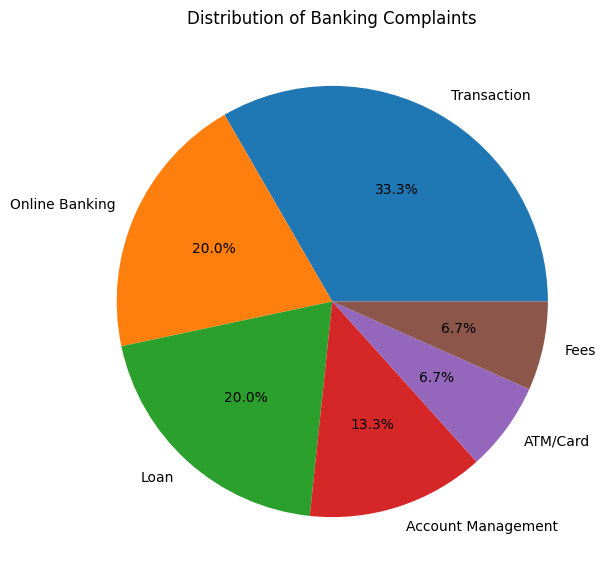

In [10]:
# COMPLAINT DISTRIBUTION

# Create pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    category_count.values,
    labels=category_count.index,
    autopct="%1.1f%%"
)

# Add title
plt.title("Distribution of Banking Complaints")

# Show graph
plt.show()

In [11]:
# FREQUENT WORD ANALYSIS

from collections import Counter

# Combine all cleaned complaints
all_words = " ".join(
    df["Clean_Complaint"]
).split()

# Count words
word_count = Counter(all_words)

# Get top 10 words
top_words = word_count.most_common(10)

# Display words
print("Most Frequent Words:")

for word, count in top_words:
    print(word, ":", count)

Most Frequent Words:
account : 4
money : 3
online : 3
banking : 3
loan : 3
deducted : 2
transaction : 2
atm : 2
cannot : 2
login : 2


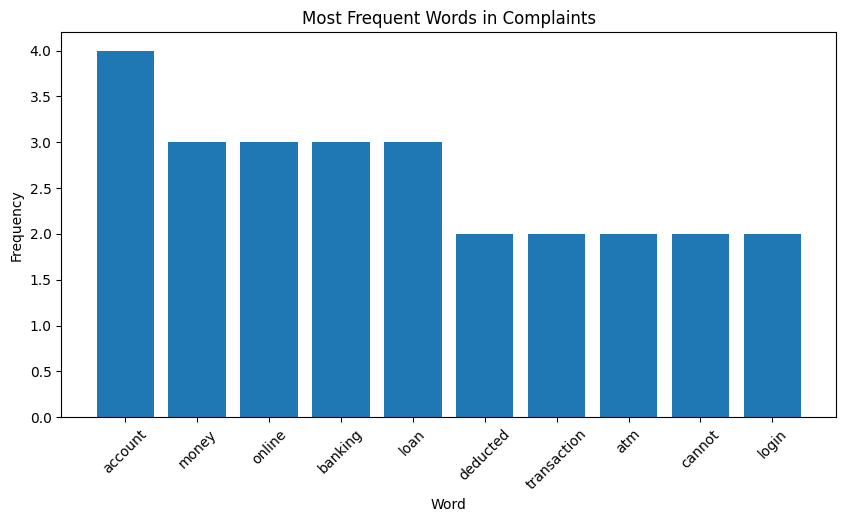

In [12]:
# FREQUENT WORD GRAPH

# Create DataFrame
word_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

# Create graph
plt.figure(figsize=(10, 5))

plt.bar(
    word_df["Word"],
    word_df["Frequency"]
)

# Add title
plt.title("Most Frequent Words in Complaints")

# Add labels
plt.xlabel("Word")
plt.ylabel("Frequency")

# Rotate labels
plt.xticks(rotation=45)

# Show graph
plt.show()

In [2]:
# PROJECT SUMMARY


print("==========================================")
print("       BANKING COMPLAINT ANALYSIS")
print("==========================================")

print("1. Banking complaint data collected")
print("2. Complaint text preprocessed")
print("3. Complaints categorized")
print("4. Frequent banking issues identified")
print("5. Analytical report generated")
print("6. Visualizations created")

print("==========================================")
print("       PROJECT COMPLETED")
print("==========================================")

       BANKING COMPLAINT ANALYSIS
1. Banking complaint data collected
2. Complaint text preprocessed
3. Complaints categorized
4. Frequent banking issues identified
5. Analytical report generated
6. Visualizations created
       PROJECT COMPLETED
